In [16]:
from alc import *
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os
import pandas as pd
from labos.labo_01_fundamentos import transpuesta
from labos.labo_05_factorizacion_qr import calculaQR
from labos.labo_08_svd import svd_reducida


In [17]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)

## Análisis

### Matriz de confusión de métodos

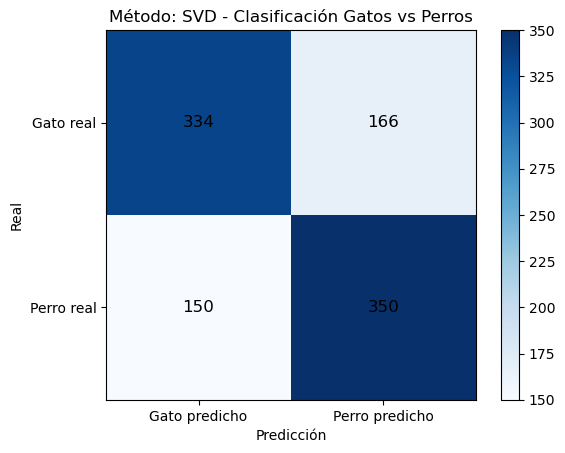

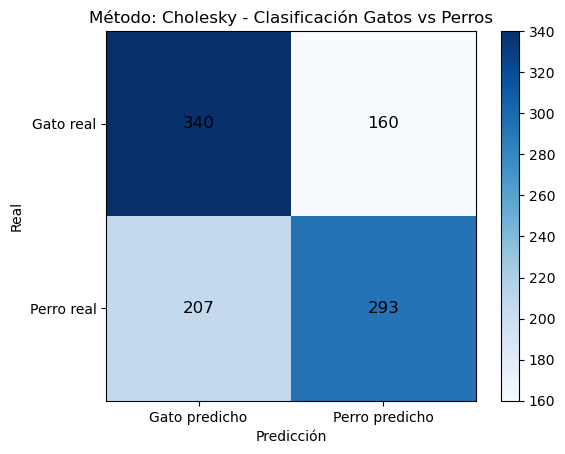

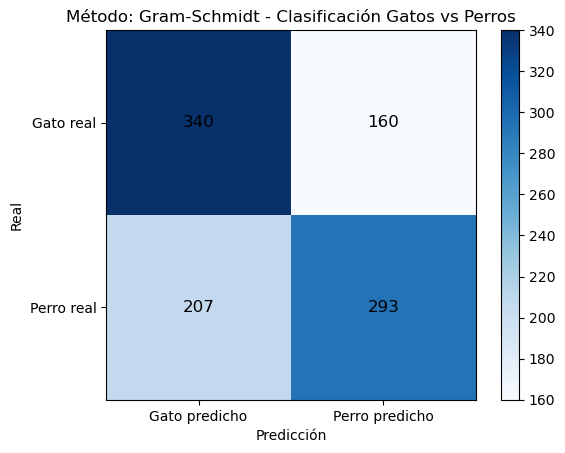

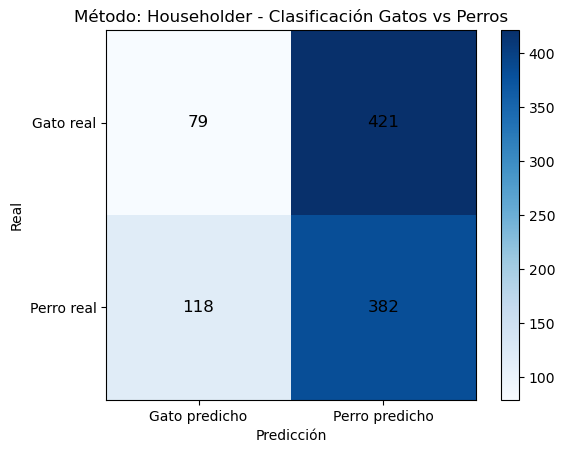

In [18]:
nombres_metodos = ["SVD", "Cholesky", "Gram-Schmidt", "Householder"]

# Código de ploteo

# Creamos las listas que usamos
lista_W = list()
aciertoGatos = list()
aciertoPerros = list()
precisionModelo = list()

# Agregamos los W de cada método
lista_W.append(np.load("W_svd.npy"))
lista_W.append(np.load("W_e_primitivas.npy"))
lista_W.append(np.load("W_gramschmidt.npy"))
lista_W.append(np.load("W_householder.npy"))

for W in lista_W:

    r = transpuesta(W @ Xv)

    # Convertimos las predicciones: elegimos el índice del valor máximo
    predicciones = np.argmax(r, axis=1)
    etiquetas_reales = np.argmax(Yv, axis=1)


    # Creamos la matriz de confusión
    matriz_conf = confusion_matrix(etiquetas_reales, predicciones)

    # Agregamos aciertos para luego crear la tabla
    aciertoGatos.append(matriz_conf[0,0]/5) 
    aciertoPerros.append(matriz_conf[1,1]/5)
    precisionModelo.append((matriz_conf[0,0] + matriz_conf[1,1])/10)

    plt.imshow(matriz_conf, cmap='Blues')
    plt.colorbar()

    # Mostramos los valores dentro de cada celda
    for i in range(matriz_conf.shape[0]):
        for j in range(matriz_conf.shape[1]):
            plt.text(j, i, matriz_conf[i, j],
                     ha='center', va='center', color='black', fontsize=12)


    # Etiquetas de ejes
    plt.xticks([0, 1], ['Gato predicho', 'Perro predicho'])
    plt.yticks([0, 1], ['Gato real', 'Perro real'])

    plt.xlabel('Predicción')
    plt.ylabel('Real')

    metodo = nombres_metodos.pop(0)

    plt.title(f"Método: {metodo} - Clasificación Gatos vs Perros")
    plt.show()

### Tabla comparativa de resultados de cada metodología

In [19]:
data = {
    "Tasa de aciertos (gatos)": aciertoGatos,
    "Tasa de aciertos (perros)": aciertoPerros,
    "Acierto total": precisionModelo
}


metodos = [
    "SVD",
    "Cholesky",
    "Gram-Schmidt",
    "Householder"
]

df = pd.DataFrame(data, index=metodos)

print("\n=== Comparación de Métodos ===\n")
print(df.to_string())



=== Comparación de Métodos ===

              Tasa de aciertos (gatos)  Tasa de aciertos (perros)  Acierto total
SVD                               66.8                       70.0           68.4
Cholesky                          68.0                       58.6           63.3
Gram-Schmidt                      68.0                       58.6           63.3
Householder                       15.8                       76.4           46.1


## Síntesis Final

Una vez finalizadas nuestras experimentaciones, analizamos cuáles metodologías son las más adecuadas usando como parámetros de evaluación: la complejidad, la precisión de aciertos y el equilibrio de las predicciones.
## Resultados
El método de SVD obtuvo una tasa de aciertos de gatos del 66,8%, de perros del 70% y una precisión total de 68,4%. Se puede observar que la tasa de aciertos entre ambos es similar. Esto es una buena señal, ya que nos muestra una matriz de confusión que conserva equilibrio en los resultados, es decir, no existen sesgos hacia alguna de las dos clases.

Con el método de Cholesky, los gatos bien asignados fueron el 68%, los perros el 58,6%, y el acierto total fue de 63,3%. En este caso hay una diferencia mayor entre las dos clases, teniendo una tendencia a pronosticar gatos. Suponemos que la alta tasa de aciertos sobre gatos se debe a esta.

Para el método de Gram-Schmidt, se puede ver que los resultados en la predicción son exactamente iguales a los del anterior, y si miramos las matrices de confusión veremos que ambas son idénticas.

Por último, con respecto a HouseHolder, obtuvimos una tasa de acierto del 15% en gatos, de 76,4 % en perros y un 46,1% total. Se ve una clara tendencia a pronosticar perro, pudiéndose observar que el 80% de las imágenes las cataloga como este animal.
## Análisis de complejidad
Todos los métodos tienen una complejidad O(n³), exceptuando el de SVD, el cual tiene complejidad O(n⁴), la cual se podría reducir optimizando la función diagRH. Sin embargo, el método de Cholesky resultó ser el mas rápido; creemos que esto se debe a que la constante es mucho más chica que en los demás. Luego le siguen los métodos por QR, y por último el método más pesado es el de SVD. Para estos cálculos tomamos únicamente nuestras implementaciones (sin usar las de numpy).
## Conclusión
Nuestra conclusión es que el modelo entrenado con la descomposición de valores singulares es el mejor. Este método muestra un balance entre efectividad y equilibrio de resultados. Sin embargo, es el más costoso, por lo que en una situación donde el costo sea relevante puede ser mejor el método de Cholesky. Claramente el peor fue el de HouseHolder, puesto que creemos que la tasa de efectividad(tanto total como de perros) se debe a que está sesgado hacia los perros.

Entonces, en un escenario donde el costo no sea algo a tener en cuenta, el mejor método es el de SVD, mientras que si el costo es importante, Cholesky podría ser la mejor opción.